# Childcare Affordability Analysis

How much of their household income do U.S. families spend on center-based childcare for children from birth to age 5?

In [2]:
# import libraries
import pandas as pd

# import dataset
file_path = 'nationaldatabaseofchildcareprices.xlsx'
df = pd.read_excel(file_path)

In [3]:
# check column names
for col in df.columns:
    print(col)


State_Name
State_Abbreviation
County_Name
County_FIPS_Code
StudyYear
UNR_16
FUNR_16
MUNR_16
UNR_20to64
FUNR_20to64
MUNR_20to64
FLFPR_20to64
FLFPR_20to64_Under6
FLFPR_20to64_6to17
FLFPR_20to64_Under6_6to17
MLFPR_20to64
PR_F
PR_P
MHI
ME
FME
MME
MHI_2018
ME_2018
FME_2018
MME_2018
TotalPop
OneRace
OneRace_W
OneRace_B
OneRace_I
OneRace_A
OneRace_H
OneRace_Other
TwoRaces
Hispanic
Households
H_Under6_BothWork
H_Under6_FWork
H_Under6_MWork
H_Under6_SingleM
H_6to17_BothWork
H_6to17_Fwork
H_6to17_Mwork
H_6to17_SingleM
EMP_M
MEMP_M
FEMP_M
EMP_Service
MEMP_Service
FEMP_Service
EMP_Sales
MEMP_Sales
FEMP_Sales
EMP_N
MEMP_N
FEMP_N
EMP_P
MEMP_P
FEMP_P
iUNR_16
iFUNR_16
iMUNR_16
iUNR_20to64
iFUNR_20to64
iMUNR_20to64
iFLFPR_20to64
iFLFPR_20to64_Under6
iFLFPR_20to64_6to17
iFLFPR_20to64_Under6_6to17
iMLFPR_20to64
iPR_F
iPR_P
iMHI
iME
iFME
iMME
iMHI_2018
iME_2018
iFME_2018
iMME_2018
iTotalPop
iOneRace
iOneRace_W
iOneRace_B
iOneRace_I
iOneRace_A
iOneRace_H
iOneRace_Other
iTwoRaces
iHispanic
iHouseholds
iH_Un

In [4]:
# select columns I need 
cols_needed = [
    'State_Name', 'County_Name', 'StudyYear',
    'MCBto5', # median center-based childcare cost for children from birth to 5
    'MHI' # median household income
]
df_affordability = df[cols_needed].copy()

In [5]:
# drop rows with missing values
df_affordability = df_affordability.dropna(subset=['MCBto5', 'MHI'])

In [6]:
# check to see if MCBto5 is weekly, monthly or annually
df_affordability[['State_Name', 'County_Name', 'StudyYear', 'MCBto5']].head(10)


,State_Name,County_Name,StudyYear,MCBto5
0,Alabama,Autauga County,2008,104.95
1,Alabama,Autauga County,2009,105.11
2,Alabama,Autauga County,2010,105.28
3,Alabama,Autauga County,2011,105.45
4,Alabama,Autauga County,2012,105.61
5,Alabama,Autauga County,2013,105.78
6,Alabama,Autauga County,2014,105.95
7,Alabama,Autauga County,2015,109.56
8,Alabama,Autauga County,2016,113.18
9,Alabama,Autauga County,2017,116.79


I checked in the official Technical Guide and it is weekly just to make sure.

In [8]:
# calculate the % of income spent on childcare
# MCBto5 is weekly. I want to annualize it by multiplying by 52
df_affordability['ChildcarePctIncome'] = (df_affordability['MCBto5'] * 52) / df_affordability['MHI'] * 100


In [9]:
# check for extreme outliers
df_affordability['ChildcarePctIncome'].describe()

count    23593.000000
mean        16.376177
std          4.561023
min          3.270863
25%         13.316588
50%         15.867408
75%         18.535809
max         54.300643
Name: ChildcarePctIncome, dtype: float64

In [10]:
# group by state and compute average % across counties
state_affordability = df_affordability.groupby('State_Name')['ChildcarePctIncome'].mean().reset_index()

In [11]:
# sort the results
state_affordability_sorted = state_affordability.sort_values(by='ChildcarePctIncome', ascending=False)

In [12]:
# display the to 10 affordable states
print("Top 10 Least Affordable States:")
print(state_affordability_sorted.head(10))

Top 10 Least Affordable States:
              State_Name  ChildcarePctIncome
45            Washington           28.603535
4             California           25.457827
8   District of Columbia           24.563400
20         Massachusetts           24.187928
5               Colorado           22.874505
30              New York           21.792327
2                Arizona           19.927864
11                Hawaii           19.660744
31        North Carolina           19.575536
37          Rhode Island           19.240195


In [13]:
# display the to 10 most affordable states
print("\nTop 10 Most Affordable States:")
print(state_affordability_sorted.tail(10))


Top 10 Most Affordable States:
      State_Name  ChildcarePctIncome
10       Georgia           14.221646
26      Nebraska           13.840160
42          Utah           13.790929
12         Idaho           13.630484
24      Missouri           13.605337
32  North Dakota           13.473460
48       Wyoming           13.441754
23   Mississippi           11.865556
15        Kansas           11.607985
39  South Dakota           11.291810


## Summary of Findings

For this project, I analyzed data from the National Database of Childcare Prices. My goal was to explore childcare affordability across the United States by calculating the percentage of household income that families spend on childcare for children birth to age 5 in center-based care.

I used two key variables from the dataset: MCBto5, which represents the median weekly childcare price for center-based care for children birth to age 5, and MHI, which is the median household income. After confirming through the official Technical Guide that MCBto5 is a weekly price (and validating this by checking the data values), I calculated the annual childcare cost by multiplying MCBto5 by 52. I then computed the percentage of household income spent on childcare using this formula: (Annual Childcare Cost / MHI) * 100.

I excluded any rows where MCBto5 or MHI was missing, as these are necessary to compute affordability. I also checked for extreme outliers in the resulting percentages, but none were found (the maximum value was 54.3%, which is high but realistic).

The analysis shows that families in Washington are spending an average of about 28.6% of their household income on childcare for children birth to age 5 in center-based care which is the highest in the country. Other expensive states include California (25.5%), the District of Columbia (24.6%), and Massachusetts (24.2%). These numbers are far above the federal benchmark of 7% of income, which highlights how unaffordable childcare has become for many families. On the other end of the spectrum, states like South Dakota (11.3%), Kansas (11.6%), and Mississippi (11.9%) had the lowest average percentage of household income spent on childcare. While these numbers are still above the federal benchmark of 7%, they reflect somewhat better affordability compared to higher-cost states.

For this analysis, I treated MCBto5 as a weekly price, based on what was stated in the Technical Guide and confirmed by checking the data. I calculated the annual childcare cost by multiplying the weekly amount by 52. The percentages that resulted looked reasonable, so I didn’t filter out any additional data. One item that still needs clarification is whether the childcare prices reflect full-time care or part-time care. Additionally, exploring differences between urban and rural affordability would be useful in future analysis.

To help communicate my message, I plan to use three different tools. First, I’ll create a PowerPoint presentation to share the key findings and show why childcare affordability needs attention from policymakers. Second, I want to make an infographic that clearly shows how much income families in different states are spending on childcare. This will be a good way to help the general public and advocacy groups understand the issue. Third, I’d like to build an interactive dashboard in Power BI or Tableau so users can explore the data themselves and see how childcare affordability looks across different states and over time.

In [ ]:
import pandas as pd

# 1. Load the Excel file
file_path = 'nationaldatabaseofchildcareprices.xlsx'  # adjust path if needed
df = pd.read_excel(file_path)

# 2. Keep only the columns we need and drop missing
df = df[['State_Name', 'County_Name', 'StudyYear', 'MCBto5', 'MHI']].dropna()

# 3. Compute % of household income spent on childcare
df['ChildcarePctIncome'] = df['MCBto5'] * 52 / df['MHI'] * 100

# Now df is ready for plotting


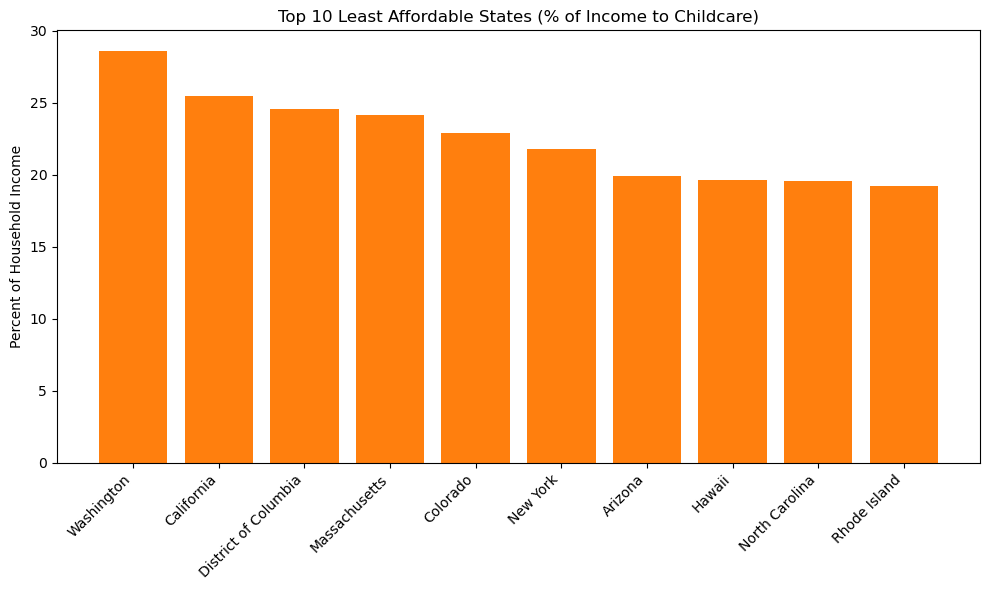

In [31]:
import matplotlib.pyplot as plt

# Compute state-level average affordability and sort
state_avg = (
    df.groupby('State_Name')['ChildcarePctIncome']
      .mean()
      .sort_values(ascending=False)
      .reset_index()
)

# Select top 10
top10_least = state_avg.head(10)

# Plot
plt.figure(figsize=(10,6))
plt.bar(top10_least['State_Name'], top10_least['ChildcarePctIncome'], color='C1')
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Least Affordable States (% of Income to Childcare)')
plt.ylabel('Percent of Household Income')
plt.tight_layout()

# Save the figure
plt.savefig('top10_least_affordable_states.png', dpi=300)
plt.show()


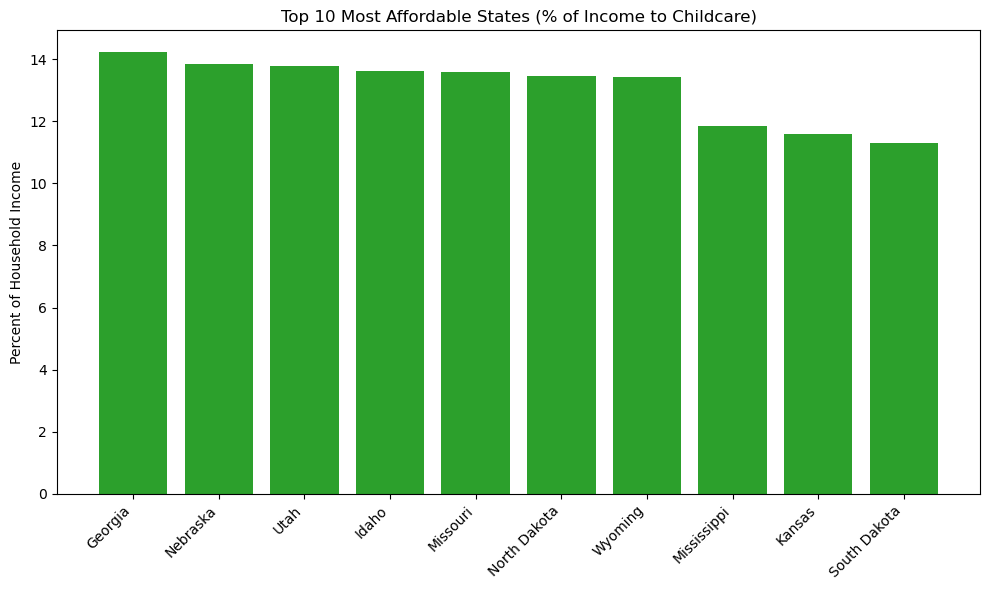

In [33]:
# Re-use `state_avg` from above

# Select bottom 10
top10_most = state_avg.tail(10)

# Plot
plt.figure(figsize=(10,6))
plt.bar(top10_most['State_Name'], top10_most['ChildcarePctIncome'], color='C2')
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Most Affordable States (% of Income to Childcare)')
plt.ylabel('Percent of Household Income')
plt.tight_layout()

# Save the figure
plt.savefig('top10_most_affordable_states.png', dpi=300)
plt.show()


In [44]:
# After running your data‐load/clean cell, inspect the columns
print(df.columns.tolist())


['State_Name', 'State_Abbreviation', 'StudyYear', 'MCBto5', 'MHI', 'ChildcarePctIncome']


In [56]:
import pandas as pd
import plotly.express as px
from IPython.display import Image

# 1) Reload the full sheet, keeping abbreviations
file_path = 'nationaldatabaseofchildcareprices.xlsx'
df = pd.read_excel(file_path)

# 2) Subset and drop only rows missing cost/income
df = df[['State_Name','State_Abbreviation','StudyYear','MCBto5','MHI']].dropna(subset=['MCBto5','MHI'])

# 3) Recompute the percent‐of‐income metric
df['ChildcarePctIncome'] = df['MCBto5'] * 52 / df['MHI'] * 100

# 4) Build the state‐level average keyed on the two‐letter code
state_avg_abbr = (
    df.groupby('State_Abbreviation')['ChildcarePctIncome']
      .mean()
      .reset_index()
)

# 5) Create and display the choropleth
fig = px.choropleth(
    state_avg_abbr,
    locations='State_Abbreviation',
    locationmode='USA-states',
    color='ChildcarePctIncome',
    scope='usa',
    color_continuous_scale='Viridis',
    labels={'ChildcarePctIncome':'% Income to Childcare'},
    title='Childcare Affordability by State (% of Household Income)'
)





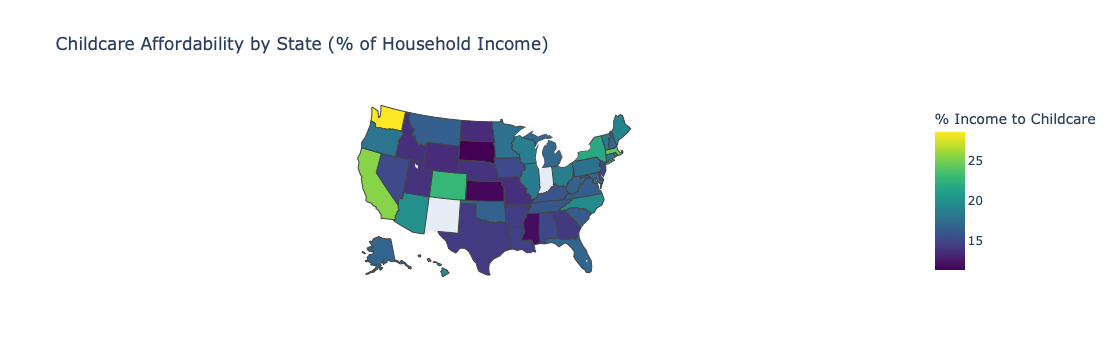

In [53]:
fig.show()


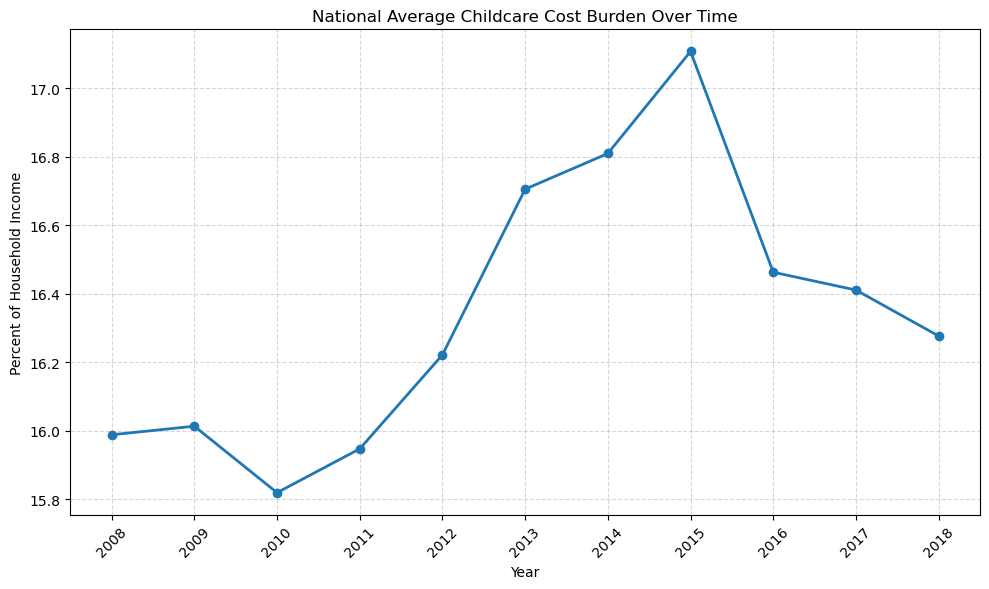

In [57]:
import matplotlib.pyplot as plt

# 5) Trend line: National average over time
trend = df.groupby('StudyYear')['ChildcarePctIncome'].mean().reset_index()

plt.figure(figsize=(10,6))
plt.plot(trend['StudyYear'], trend['ChildcarePctIncome'], marker='o', linewidth=2)
plt.title('National Average Childcare Cost Burden Over Time')
plt.xlabel('Year')
plt.ylabel('Percent of Household Income')
plt.xticks(trend['StudyYear'], rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()

# Save the figure
plt.savefig('national_trend.png', dpi=300)
plt.show()


In [62]:
import pandas as pd

# 1) Reload the data, keeping County_Name this time
file_path = 'nationaldatabaseofchildcareprices.xlsx'
df = pd.read_excel(file_path)

# 2) Subset with County_Name and drop rows missing cost/income
df = df[['State_Name','State_Abbreviation','County_Name','StudyYear','MCBto5','MHI']].dropna(subset=['MCBto5','MHI'])

# 3) Recompute the affordability metric
df['ChildcarePctIncome'] = df['MCBto5'] * 52 / df['MHI'] * 100


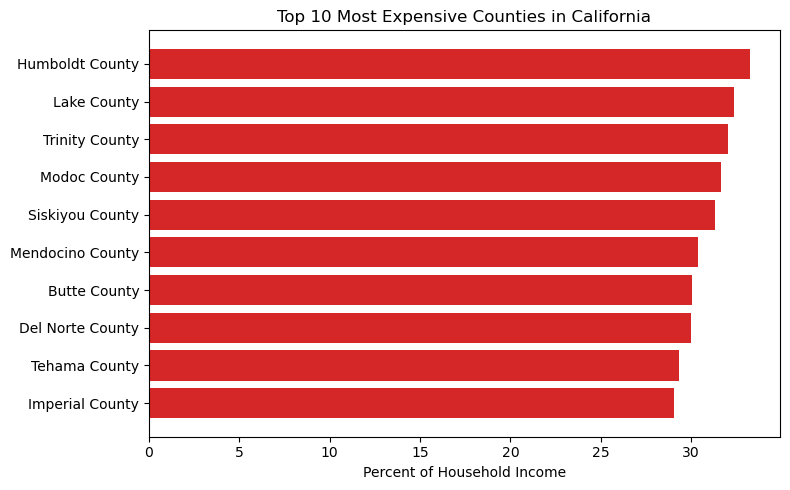

In [63]:
import matplotlib.pyplot as plt

# Pick a state (you can parameterize this later in a dashboard)
state = 'California'

# Compute county-level averages for that state
df_state = df[df['State_Name'] == state]
county_avg = (
    df_state.groupby('County_Name')['ChildcarePctIncome']
            .mean()
            .sort_values(ascending=False)
            .reset_index()
)
top10_counties = county_avg.head(10)

plt.figure(figsize=(8,5))
plt.barh(top10_counties['County_Name'][::-1],  # reverse for ascending display
         top10_counties['ChildcarePctIncome'][::-1],
         color='C3')
plt.xlabel('Percent of Household Income')
plt.title(f'Top 10 Most Expensive Counties in {state}')
plt.tight_layout()
plt.savefig('top10_counties_state.png', dpi=300)
plt.show()


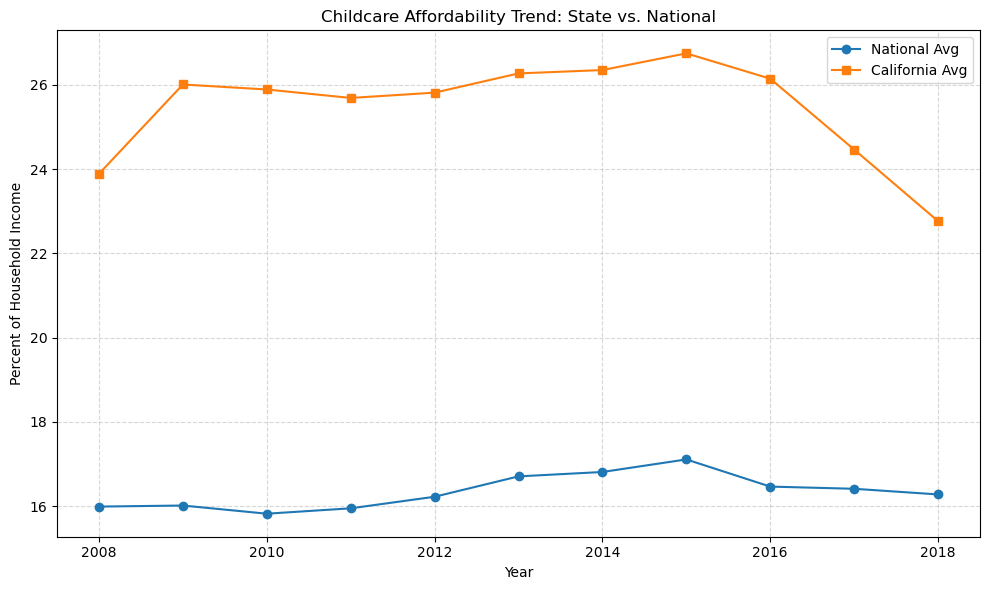

In [66]:
import matplotlib.pyplot as plt

# National trend (reuse from before)
trend_nat = df.groupby('StudyYear')['ChildcarePctIncome'].mean().reset_index()

# State trend
state = 'California'
trend_state = (
    df[df['State_Name'] == state]
    .groupby('StudyYear')['ChildcarePctIncome']
    .mean()
    .reset_index()
)

plt.figure(figsize=(10,6))
plt.plot(trend_nat['StudyYear'], trend_nat['ChildcarePctIncome'], marker='o',
         label='National Avg')
plt.plot(trend_state['StudyYear'], trend_state['ChildcarePctIncome'], marker='s',
         label=f'{state} Avg')
plt.title('Childcare Affordability Trend: State vs. National')
plt.xlabel('Year')
plt.ylabel('Percent of Household Income')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('state_vs_national_trend.png', dpi=300)
plt.show()


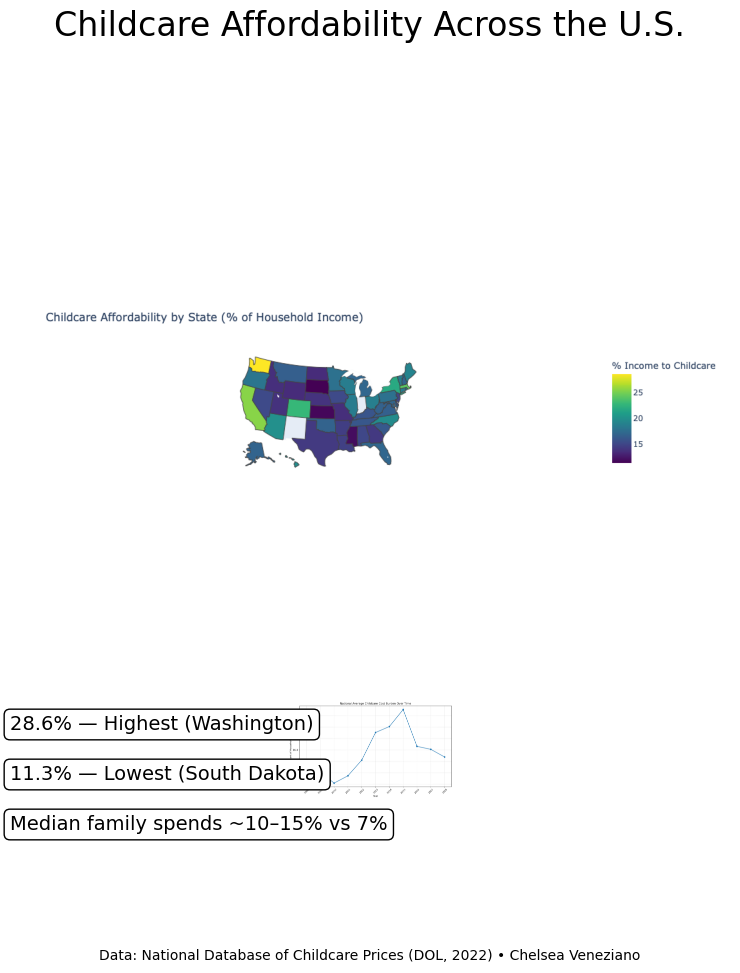

In [86]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Load images
map_img   = mpimg.imread('us_affordability_map.png')
trend_img = mpimg.imread('national_trend.png')

# Create figure
fig = plt.figure(figsize=(8, 10))
fig.suptitle("Childcare Affordability Across the U.S.", fontsize=24, y=0.97)

# 1) Map area (smaller height, lifted up)
ax_map = fig.add_axes([0.05, 0.30, 0.90, 0.55])  # [left, bottom, width, height]
ax_map.imshow(map_img)
ax_map.axis('off')

# 2) Sparkline area (moved down)
ax_spark = fig.add_axes([0.10, 0.18, 0.80, 0.10])
ax_spark.imshow(trend_img)
ax_spark.axis('off')

# 3) Callouts (moved lower)
callouts = [
    ("28.6% — Highest (Washington)",       0.05, 0.25),
    ("11.3% — Lowest (South Dakota)",      0.05, 0.20),
    ("Median family spends ~10–15% vs 7%", 0.05, 0.15),
]
for text, x, y in callouts:
    fig.text(x, y, text, transform=fig.transFigure,
             fontsize=14,
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))

# 4) Footer
fig.text(0.5, 0.02,
         "Data: National Database of Childcare Prices (DOL, 2022) • Chelsea Veneziano",
         ha='center', fontsize=10)

# Save and show
fig.savefig("childcare_infographic.png", dpi=300, bbox_inches='tight')
plt.show()
